# Analisis de Opiniones Turisticas - Quito Old Town
## TripAdvisor Reviews - NLP Pipeline Completo

**Dataset**: 598 reviews de TripAdvisor  
**Destino**: Quito Old Town, Ecuador  
**Fuente**: https://www.tripadvisor.com/Attraction_Review-g294308-d315636

---

## 1. Explicacion del proceso realizado

Este analisis aplica tecnicas de Procesamiento de Lenguaje Natural (NLP) sobre 598 reseñas turisticas extraidas de TripAdvisor para el destino **Quito Old Town** en Ecuador.

### Pipeline completo:
1. **Extraccion de datos**: Scraping web con Playwright (TypeScript)
2. **Limpieza y preprocesamiento**: URLs, emojis, caracteres especiales, normalizacion
3. **Tokenizacion**: NLTK word_tokenize con ejemplos antes/despues
4. **Eliminacion de stopwords**: Español + ingles + lista personalizada
5. **Lematizacion**: Reduccion a forma base de las palabras
6. **Bag of Words**: Representacion numerica del corpus
7. **TF-IDF**: Terminos mas representativos
8. **Word Embeddings**: Word2Vec para exploracion semantica
9. **Analisis de sentimiento**: Clasificacion positivo/neutro/negativo
10. **Conclusiones**: Interpretacion de resultados

In [1]:
# INSTALAR DEPENDENCIAS (ejecutar una sola vez)
import subprocess
import sys

packages = [
    'pandas',
    'numpy',
    'scikit-learn',
    'nltk',
    'matplotlib',
    'seaborn',
    'wordcloud',
    'gensim'
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

# Verificar instalacion
print('Verificando instalaciones...')
import pandas, numpy, sklearn, nltk, matplotlib, seaborn, wordcloud, gensim
print('Todas las dependencias instaladas correctamente')

Verificando instalaciones...


c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


Todas las dependencias instaladas correctamente


In [2]:
# IMPORTS Y CONFIGURACION
# Backend inline: muestra gráficos directamente en el notebook
%matplotlib inline
import matplotlib
# matplotlib.use('Agg')  # Desactivado: no muestra outputs inline

import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import gensim
from gensim.models import Word2Vec

# Descargar recursos NLTK
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print('Todas las librerias cargadas correctamente')

Todas las librerias cargadas correctamente


In [3]:
# 2. CARGA Y EXPLORACION DEL DATASET
df = pd.read_json('reviews.json')
print(f'Total de registros: {len(df)}')
print(f'Columnas: {list(df.columns)}')
print(f'Tipos de datos:')
print(df.dtypes)
print()
df.head(10)

Total de registros: 598
Columnas: ['title', 'text', 'rating', 'date', 'user', 'userLocation']
Tipos de datos:
title                   object
text                    object
rating                   int64
date            datetime64[ns]
user                    object
userLocation            object
dtype: object



,title,text,rating,date,user,userLocation
0,Old town the place to be in Quilto,Old Town in Quilto is amazing to walk around a...,5,2026-05-03,Jason S,"Melbourne, Australia"
1,Very easily explorable on foot.,We wondered through the old city of Quito on f...,5,2026-02-08,podrozniczka60,
2,Travel Responsibly,Quito: where the sky touches the earth.Quito: ...,5,2026-01-14,Ecuador FunTrip | Travel Responsibly,Ecuador
3,A very interesting old town,"We spent three days walking in Quito, and the ...",5,2025-11-22,Régis1972,"Lancy, Switzerland"
4,Historic Center,We really enjoyed walking around the Quito mai...,5,2025-05-29,LSQRD1,"Kent, Ohio"
5,Definetely a must when in Quito!,"Quito Old Town is beautiful, there are so many...",5,2025-04-11,Kitija Sohireva,
6,"Fascinating Old Town, Be Alert After Sundown",I really liked Quito's old town. During the da...,5,2025-03-17,Gareth C,
7,Very well preserved.,The historic center of Quito is really well pr...,4,2025-02-15,Blackfields,
8,Please be aware of thieves.,My wife and I had one day to spend in Quito on...,2,2025-01-26,Mark,"Ostuni, Italy"
9,Private Guide of Quito,Spent a full day in Quito before we head to th...,5,2025-01-26,judy h,


In [4]:
# 3. ESTADISTICAS BASICAS DEL DATASET
print('=' * 60)
print('ESTADISTICAS BASICAS DEL DATASET')
print('=' * 60)
print(f'Total de reviews: {len(df)}')
print(f'Rating promedio: {df["rating"].mean():.2f}')
print(f'Rating mediano: {df["rating"].median():.1f}')
print(f'Rating minimo: {df["rating"].min()}')
print(f'Rating maximo: {df["rating"].max()}')
print(f'Desviacion estandar: {df["rating"].std():.2f}')
print()
print('Distribucion de ratings:')
print(df['rating'].value_counts().sort_index())
print()
print('Reviews con fecha:', df['date'].notna().sum())
print('Reviews con usuario:', df['user'].notna().sum())
print('Reviews con ubicacion:', df['userLocation'].notna().sum())

ESTADISTICAS BASICAS DEL DATASET
Total de reviews: 598
Rating promedio: 4.53
Rating mediano: 5.0
Rating minimo: 1
Rating maximo: 5
Desviacion estandar: 0.75

Distribucion de ratings:
rating
1      7
2      9
3     26
4    172
5    384
Name: count, dtype: int64

Reviews con fecha: 598
Reviews con usuario: 598
Reviews con ubicacion: 598


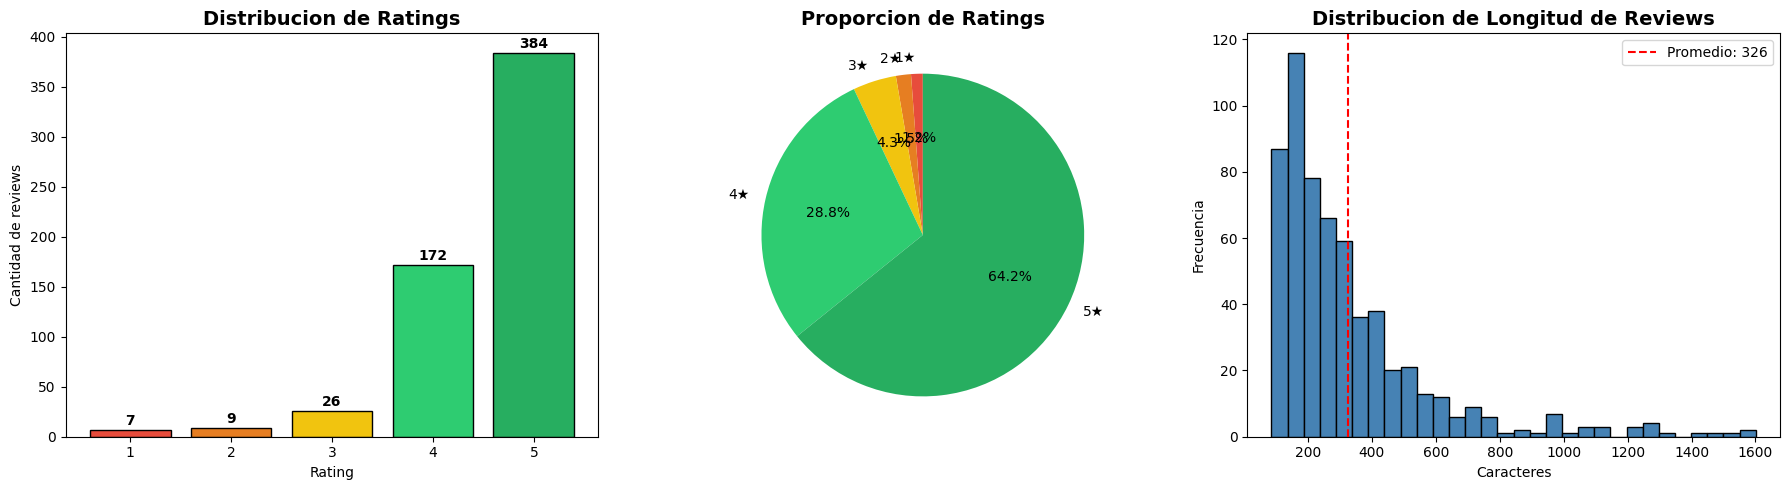


Longitud promedio: 326 caracteres
Longitud minima: 86 caracteres
Longitud maxima: 1601 caracteres


In [5]:
# GRAFICO 1: Distribucion de Ratings
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma de ratings
rating_counts = df['rating'].value_counts().sort_index()
colors_rating = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
axes[0].bar(rating_counts.index, rating_counts.values, color=colors_rating, edgecolor='black')
axes[0].set_title('Distribucion de Ratings', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Cantidad de reviews')
for i, v in enumerate(rating_counts.values):
    axes[0].text(rating_counts.index[i], v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(rating_counts.values, labels=[f'{r}★' for r in rating_counts.index],
            autopct='%1.1f%%', colors=colors_rating, startangle=90)
axes[1].set_title('Proporcion de Ratings', fontsize=14, fontweight='bold')

# Longitud de textos
df['text_len'] = df['text'].str.len()
axes[2].hist(df['text_len'], bins=30, color='steelblue', edgecolor='black')
axes[2].set_title('Distribucion de Longitud de Reviews', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Caracteres')
axes[2].set_ylabel('Frecuencia')
axes[2].axvline(df['text_len'].mean(), color='red', linestyle='--', label=f'Promedio: {df["text_len"].mean():.0f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('01_estadisticas_basicas.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nLongitud promedio: {df["text_len"].mean():.0f} caracteres')
print(f'Longitud minima: {df["text_len"].min()} caracteres')
print(f'Longitud maxima: {df["text_len"].max()} caracteres')

## 4. Limpieza y Preprocesamiento

### Decisiones tomadas:

1. **Conversion a minusculas**: Estandarizar el texto para evitar que "Quito" y "quito" se traten como palabras diferentes.

2. **Eliminacion de URLs**: Las URLs no aportan significado al analisis de sentimiento y pueden introducir ruido.

3. **Eliminacion de emojis y caracteres especiales**: Se mantienen solo letras (incluidas acentuadas: áéíóúñü) y espacios. Los emojis no son procesables por los tokenizadores de NLTK.

4. **Eliminacion de numeros**: Los numeros (precios, cantidades) no aportan al analisis de sentimiento turistico.

5. **Eliminacion de espacios multiples**: Normalizar espacios para tokenizacion limpia.

In [6]:
# 4. LIMPIEZA Y PREPROCESAMIENTO
print('=' * 60)
print('LIMPIEZA DE TEXTO')
print('=' * 60)

def limpiar_texto(texto):
    """Limpieza completa del texto"""
    if not isinstance(texto, str):
        return ''
    texto = texto.lower()                          # 1. Minusculas
    texto = re.sub(r'http\S+|www\.\S+', '', texto)  # 2. Eliminar URLs
    texto = re.sub(r'[^\w\sáéíóúñü]', ' ', texto)  # 3. Eliminar especiales (mantener acentos)
    texto = re.sub(r'\d+', '', texto)               # 4. Eliminar numeros
    texto = re.sub(r'\s+', ' ', texto).strip()      # 5. Espacios multiples
    return texto

df['text_clean'] = df['text'].apply(limpiar_texto)

# Ejemplo antes/despues
print('\n--- EJEMPLO DE LIMPIEZA (3 muestras) ---')
for i in range(3):
    print(f'\nReview {i+1}:')
    print(f'  ANTES:   {df["text"].iloc[i][:150]}...')
    print(f'  DESPUES: {df["text_clean"].iloc[i][:150]}...')

LIMPIEZA DE TEXTO

--- EJEMPLO DE LIMPIEZA (3 muestras) ---

Review 1:
  ANTES:   Old Town in Quilto is amazing to walk around and enjoy, very much like some of the European on town with the narrow street with cobblestones.Even more...
  DESPUES: old town in quilto is amazing to walk around and enjoy very much like some of the european on town with the narrow street with cobblestones even more ...

Review 2:
  ANTES:   We wondered through the old city of Quito on foot. - exploring, taking it in and enjoying. We, of course, visited the old square, several churches, bo...
  DESPUES: we wondered through the old city of quito on foot exploring taking it in and enjoying we of course visited the old square several churches boutiques a...

Review 3:
  ANTES:   Quito: where the sky touches the earth.Quito: where the sky touches the earth.The best of Ecuador to travel and get to know all the architecture and h...
  DESPUES: quito where the sky touches the earth quito where the sky touches the e

## 5. Tokenizacion

Se utiliza `word_tokenize` de NLTK, que separa el texto en tokens individuales (palabras y signos de puntuacion). Se filtran tokens que son solo puntuacion o tienen menos de 3 caracteres.

**Ejemplo**:  
- Antes: "old town in quito is amazing to walk around"  
- Despues: ['old', 'town', 'quito', 'amazing', 'walk', 'around']

In [7]:
# 5. TOKENIZACION
print('=' * 60)
print('TOKENIZACION')
print('=' * 60)

# Stopwords en español e ingles
stop_words_es = set(stopwords.words('spanish'))
stop_words_en = set(stopwords.words('english'))
stop_words = stop_words_es | stop_words_en

print(f'Stopwords español: {len(stop_words_es)}')
print(f'Stopwords ingles: {len(stop_words_en)}')
print(f'Total stopwords base: {len(stop_words)}')

def tokenizar_y_filtrar(texto):
    """Tokeniza y elimina stopwords y tokens cortos"""
    tokens = word_tokenize(texto, language='spanish')
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words and len(t) > 2]
    return tokens

df['tokens'] = df['text_clean'].apply(tokenizar_y_filtrar)

# Ejemplos antes/despues
print('\n--- EJEMPLOS DE TOKENIZACION ---')
for i in range(5):
    print(f'\nReview {i+1}:')
    print(f'  TEXTO: {df["text_clean"].iloc[i][:120]}...')
    print(f'  TOKENS: {df["tokens"].iloc[i][:12]}')

# Estadisticas de tokens
df['token_count'] = df['tokens'].apply(len)
print(f'\nPromedio de tokens por review: {df["token_count"].mean():.1f}')
print(f'Total de tokens unicos: {len(set([t for tokens in df["tokens"] for t in tokens]))}')

TOKENIZACION
Stopwords español: 313
Stopwords ingles: 198
Total stopwords base: 504

--- EJEMPLOS DE TOKENIZACION ---

Review 1:
  TEXTO: old town in quilto is amazing to walk around and enjoy very much like some of the european on town with the narrow stree...
  TOKENS: ['old', 'town', 'quilto', 'amazing', 'walk', 'around', 'enjoy', 'much', 'like', 'european', 'town', 'narrow']

Review 2:
  TEXTO: we wondered through the old city of quito on foot exploring taking it in and enjoying we of course visited the old squar...
  TOKENS: ['wondered', 'old', 'city', 'quito', 'foot', 'exploring', 'taking', 'enjoying', 'course', 'visited', 'old', 'square']

Review 3:
  TEXTO: quito where the sky touches the earth quito where the sky touches the earth the best of ecuador to travel and get to kno...
  TOKENS: ['quito', 'sky', 'touches', 'earth', 'quito', 'sky', 'touches', 'earth', 'best', 'ecuador', 'travel', 'get']

Review 4:
  TEXTO: we spent three days walking in quito and the city really seduce

ANALISIS DE STOPWORDS PERSONALIZADAS

Top 30 palabras mas frecuentes (sin stopwords base):
  old                    435
  quito                  359
  town                   342
  churches               224
  city                   189
  around                 166
  beautiful              165
  people                 162
  many                   160
  see                    149
  walking                134
  buildings              133
  streets                128
  visit                  128
  great                  126
  tour                   126
  area                   123
  day                    112
  shops                  105
  place                  105
  walk                   103
  time                   102
  one                    100
  architecture            99
  lots                    98
  well                    92
  nice                    90
  history                 90
  good                    87
  restaurants             84

Stopwords personalizadas agregadas: 47

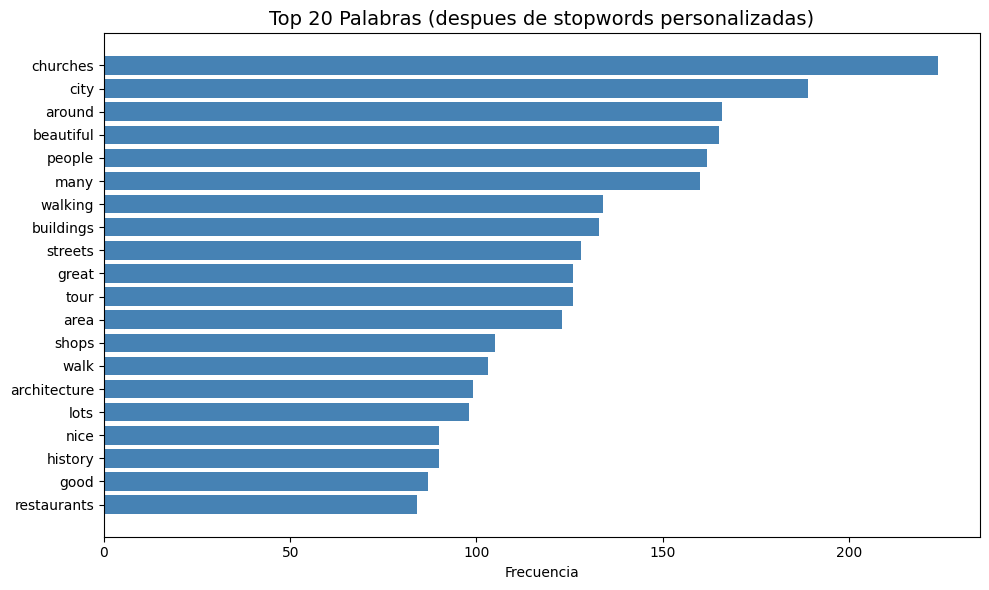

In [8]:
# 6. ANALISIS DE STOPWORDS PERSONALIZADAS
print('=' * 60)
print('ANALISIS DE STOPWORDS PERSONALIZADAS')
print('=' * 60)

# Analizar palabras mas frecuentes que NO estan en stopwords
all_tokens = [t for tokens in df['tokens'] for t in tokens]
freq_dist = nltk.FreqDist(all_tokens)

print('\nTop 30 palabras mas frecuentes (sin stopwords base):')
for word, count in freq_dist.most_common(30):
    print(f'  {word:20s} {count:5d}')

# Agregar stopwords personalizadas para este corpus turistico
stop_words_custom = {
    'also', 'one', 'would', 'could', 'get', 'us', 'really', 'much',
    'well', 'like', 'just', 'went', 'got', 'even', 'took', 'came',
    'two', 'first', 'day', 'time', 'back', 'see', 'make', 'go',
    'place', 'visit', 'town', 'quito', 'old', 'ecuador', 'review',
    'per', 'del', 'las', 'los', 'una', 'por', 'que', 'very',
    'are', 'was', 'were', 'been', 'have', 'has', 'had', 'not'
}
stop_words.update(stop_words_custom)

print(f'\nStopwords personalizadas agregadas: {len(stop_words_custom)}')
print(f'Total stopwords final: {len(stop_words)}')

# Re-aplicar filtrado
df['tokens'] = df['text_clean'].apply(tokenizar_y_filtrar)
df['token_count'] = df['tokens'].apply(len)

# Grafico: palabras mas frecuentes despues de stopwords personalizadas
all_tokens_clean = [t for tokens in df['tokens'] for t in tokens]
freq_clean = nltk.FreqDist(all_tokens_clean)

fig, ax = plt.subplots(figsize=(10, 6))
top20 = freq_clean.most_common(20)
ax.barh([w for w, c in top20][::-1], [c for w, c in top20][::-1], color='steelblue')
ax.set_title('Top 20 Palabras (despues de stopwords personalizadas)', fontsize=14)
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.savefig('02_top20_despues_stopwords.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# 7. LEMATIZACION
print('=' * 60)
print('LEMATIZACION')
print('=' * 60)

# Usar WordNetLemmatizer de NLTK
lemmatizer = WordNetLemmatizer()

def lematizar_tokens(tokens):
    """Aplica lematizacion a los tokens"""
    return [lemmatizer.lemmatize(t) for t in tokens]

df['tokens_lemma'] = df['tokens'].apply(lematizar_tokens)
df['text_processed'] = df['tokens_lemma'].apply(lambda x: ' '.join(x))

# Ejemplos de lematizacion
print('\n--- EJEMPLOS DE LEMATIZACION ---')
for i in range(5):
    original = df['tokens'].iloc[i][:8]
    lemma = df['tokens_lemma'].iloc[i][:8]
    print(f'\nReview {i+1}:')
    print(f'  Originales: {original}')
    print(f'  Lemma:      {lemma}')

# Mostrar casos donde lematizacion cambio la palabra
print('\n--- CASOS DONDE LEMATIZACION CAMBIO LA PALABRA ---')
cambios = []
for tokens, lemmas in zip(df['tokens'], df['tokens_lemma']):
    for t, l in zip(tokens, lemmas):
        if t != l:
            cambios.append((t, l))
cambios_unicos = list(set(cambios))[:20]
for orig, lem in cambios_unicos:
    print(f'  {orig:20s} -> {lem}')

LEMATIZACION

--- EJEMPLOS DE LEMATIZACION ---

Review 1:
  Originales: ['quilto', 'amazing', 'walk', 'around', 'enjoy', 'european', 'narrow', 'street']
  Lemma:      ['quilto', 'amazing', 'walk', 'around', 'enjoy', 'european', 'narrow', 'street']

Review 2:
  Originales: ['wondered', 'city', 'foot', 'exploring', 'taking', 'enjoying', 'course', 'visited']
  Lemma:      ['wondered', 'city', 'foot', 'exploring', 'taking', 'enjoying', 'course', 'visited']

Review 3:
  Originales: ['sky', 'touches', 'earth', 'sky', 'touches', 'earth', 'best', 'travel']
  Lemma:      ['sky', 'touch', 'earth', 'sky', 'touch', 'earth', 'best', 'travel']

Review 4:
  Originales: ['spent', 'three', 'days', 'walking', 'city', 'seduced', 'historic', 'centre']
  Lemma:      ['spent', 'three', 'day', 'walking', 'city', 'seduced', 'historic', 'centre']

Review 5:
  Originales: ['enjoyed', 'walking', 'around', 'main', 'square', 'parts', 'historic', 'center']
  Lemma:      ['enjoyed', 'walking', 'around', 'main', 'squ

BAG OF WORDS
Vocabulario: 1000 palabras
Matriz BoW: (598, 1000) (reviews x palabras)

Top 20 palabras mas frecuentes (BoW):
     palabra  frecuencia
      church         271
      street         210
        city         200
         lot         169
      around         166
   beautiful         165
      people         163
        many         160
        area         148
    building         146
        tour         144
     walking         134
        shop         126
       great         126
       plaza         107
        walk         106
  restaurant         101
        good          99
architecture          99
      square          98


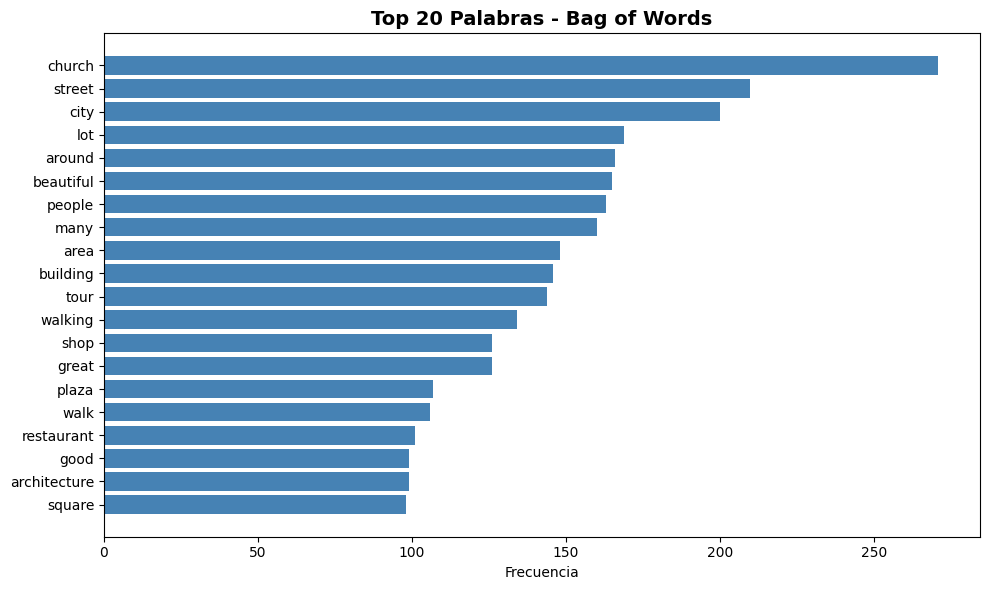

In [10]:
# 8. BAG OF WORDS
print('=' * 60)
print('BAG OF WORDS')
print('=' * 60)

bow_vectorizer = CountVectorizer(max_features=1000, min_df=2)
bow_matrix = bow_vectorizer.fit_transform(df['text_processed'])

print(f'Vocabulario: {len(bow_vectorizer.vocabulary_)} palabras')
print(f'Matriz BoW: {bow_matrix.shape} (reviews x palabras)')

bow_freq = pd.DataFrame({
    'palabra': bow_vectorizer.get_feature_names_out(),
    'frecuencia': bow_matrix.sum(axis=0).A1
}).sort_values('frecuencia', ascending=False)

print('\nTop 20 palabras mas frecuentes (BoW):')
print(bow_freq.head(20).to_string(index=False))

# Grafico BoW
fig, ax = plt.subplots(figsize=(10, 6))
top20 = bow_freq.head(20)
ax.barh(top20['palabra'][::-1], top20['frecuencia'][::-1], color='steelblue')
ax.set_title('Top 20 Palabras - Bag of Words', fontsize=14, fontweight='bold')
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.savefig('03_bow_top20.png', dpi=150, bbox_inches='tight')
plt.show()

TF-IDF
Matriz TF-IDF: (598, 1000)

Top 20 palabras por TF-IDF:
     palabra  score_tfidf
      church    26.755867
      street    22.702056
        city    22.496047
         lot    22.068304
   beautiful    21.274017
      people    20.105134
      around    19.866471
    building    19.426139
        area    19.396585
        tour    19.341810
        many    19.066745
     walking    18.698710
       great    18.533351
        shop    17.209324
        walk    16.265331
architecture    15.652988
        good    15.466541
        nice    15.353826
     history    14.689523
       plaza    14.298943


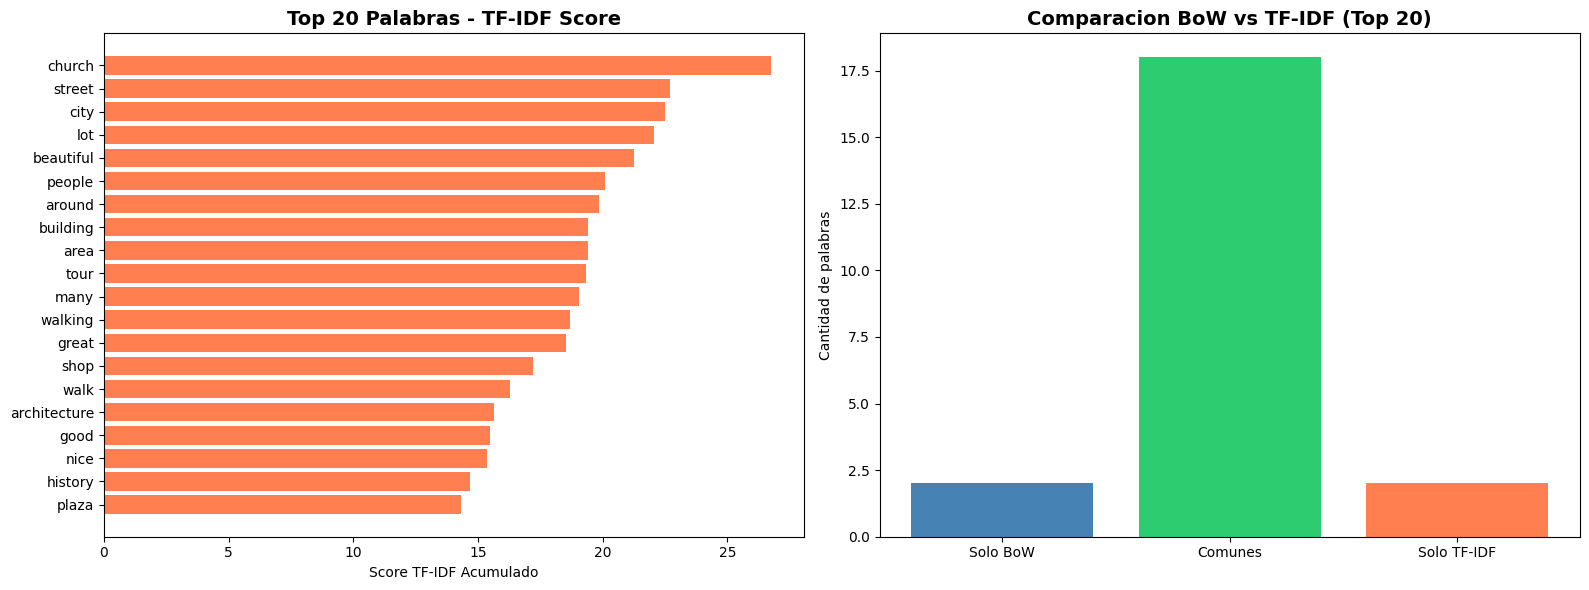


Palabras solo en BoW: {'restaurant', 'square'}
Palabras comunes: {'great', 'shop', 'architecture', 'tour', 'walking', 'church', 'plaza', 'city', 'beautiful', 'around', 'good', 'lot', 'many', 'people', 'area', 'street', 'building', 'walk'}
Palabras solo en TF-IDF: {'nice', 'history'}


In [11]:
# 9. TF-IDF
print('=' * 60)
print('TF-IDF')
print('=' * 60)

tfidf_vectorizer = TfidfVectorizer(max_features=1000, min_df=2, max_df=0.8)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['text_processed'])

print(f'Matriz TF-IDF: {tfidf_matrix.shape}')

tfidf_scores = pd.DataFrame({
    'palabra': tfidf_vectorizer.get_feature_names_out(),
    'score_tfidf': tfidf_matrix.sum(axis=0).A1
}).sort_values('score_tfidf', ascending=False)

print('\nTop 20 palabras por TF-IDF:')
print(tfidf_scores.head(20).to_string(index=False))

# Grafico TF-IDF
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top20_tfidf = tfidf_scores.head(20)
axes[0].barh(top20_tfidf['palabra'][::-1], top20_tfidf['score_tfidf'][::-1], color='coral')
axes[0].set_title('Top 20 Palabras - TF-IDF Score', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Score TF-IDF Acumulado')

# Comparar BoW vs TF-IDF
bow_top = set(bow_freq.head(20)['palabra'])
tfidf_top = set(tfidf_scores.head(20)['palabra'])
comunes = bow_top & tfidf_top
solo_bow = bow_top - tfidf_top
solo_tfidf = tfidf_top - bow_top

axes[1].bar(['Solo BoW', 'Comunes', 'Solo TF-IDF'],
            [len(solo_bow), len(comunes), len(solo_tfidf)],
            color=['steelblue', '#2ecc71', 'coral'])
axes[1].set_title('Comparacion BoW vs TF-IDF (Top 20)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Cantidad de palabras')

plt.tight_layout()
plt.savefig('04_tfidf_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nPalabras solo en BoW: {solo_bow}')
print(f'Palabras comunes: {comunes}')
print(f'Palabras solo en TF-IDF: {solo_tfidf}')

TERMINOS DISTINTIVOS POR SENTIMIENTO (TF-IDF)


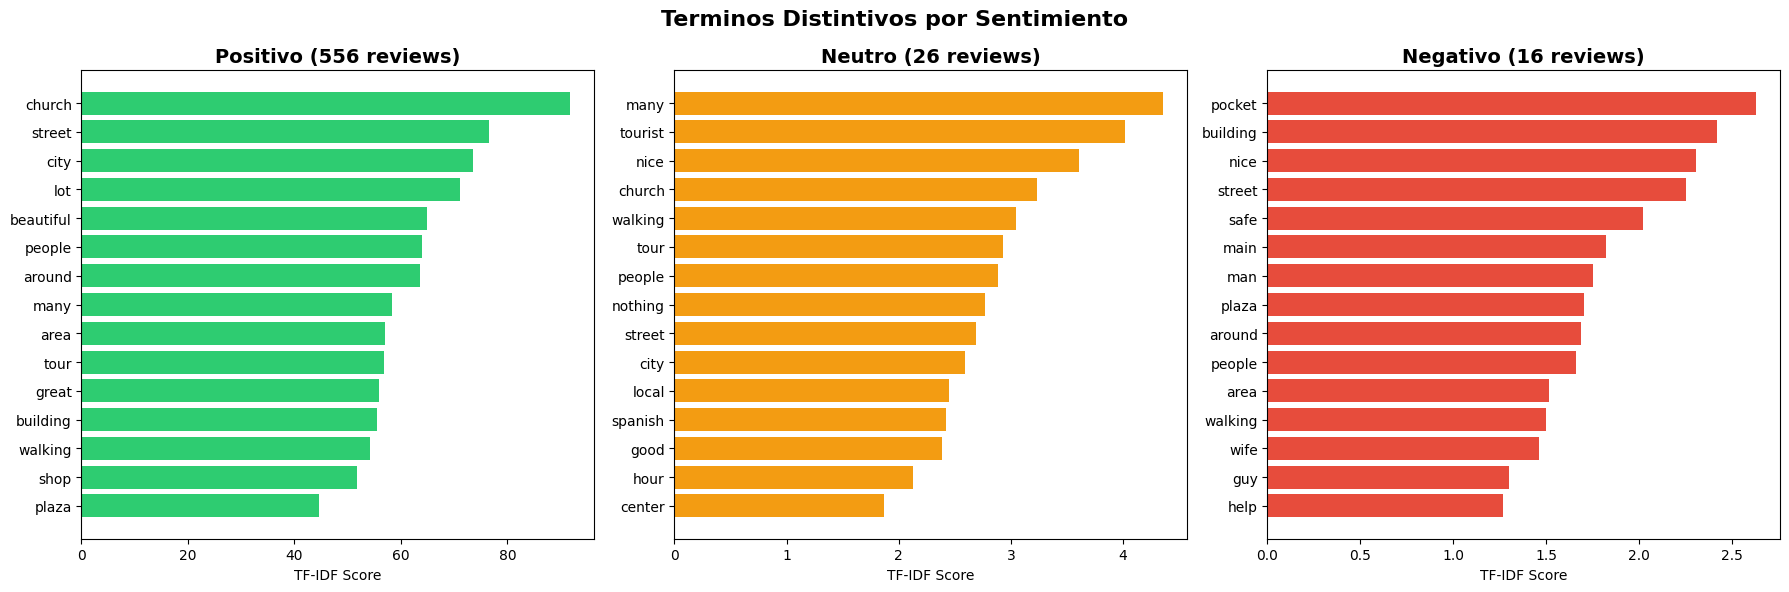

In [12]:
# 9b. TF-IDF: TERMINOS DISTINTIVOS POR SENTIMIENTO
print('=' * 60)
print('TERMINOS DISTINTIVOS POR SENTIMIENTO (TF-IDF)')
print('=' * 60)

# Clasificar sentimiento
def clasificar_sentimiento(rating):
    if rating >= 4:
        return 'Positivo'
    elif rating == 3:
        return 'Neutro'
    else:
        return 'Negativo'

df['sentimiento'] = df['rating'].apply(clasificar_sentimiento)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, sent in enumerate(['Positivo', 'Neutro', 'Negativo']):
    subset = df[df['sentimiento'] == sent]
    if len(subset) >= 5:
        tfidf_sub = TfidfVectorizer(max_features=15, min_df=2)
        try:
            matrix = tfidf_sub.fit_transform(subset['text_processed'])
            scores = pd.DataFrame({
                'palabra': tfidf_sub.get_feature_names_out(),
                'tfidf': matrix.sum(axis=0).A1
            }).sort_values('tfidf', ascending=False)
            
            color = ['#2ecc71', '#f39c12', '#e74c3c'][idx]
            axes[idx].barh(scores['palabra'][::-1], scores['tfidf'][::-1], color=color)
            axes[idx].set_title(f'{sent} ({len(subset)} reviews)', fontsize=14, fontweight='bold')
            axes[idx].set_xlabel('TF-IDF Score')
        except:
            axes[idx].text(0.5, 0.5, 'Datos insuficientes', ha='center', va='center')
            axes[idx].set_title(sent)

plt.suptitle('Terminos Distintivos por Sentimiento', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('05_tfidf_por_sentimiento.png', dpi=150, bbox_inches='tight')
plt.show()

WORD CLOUD


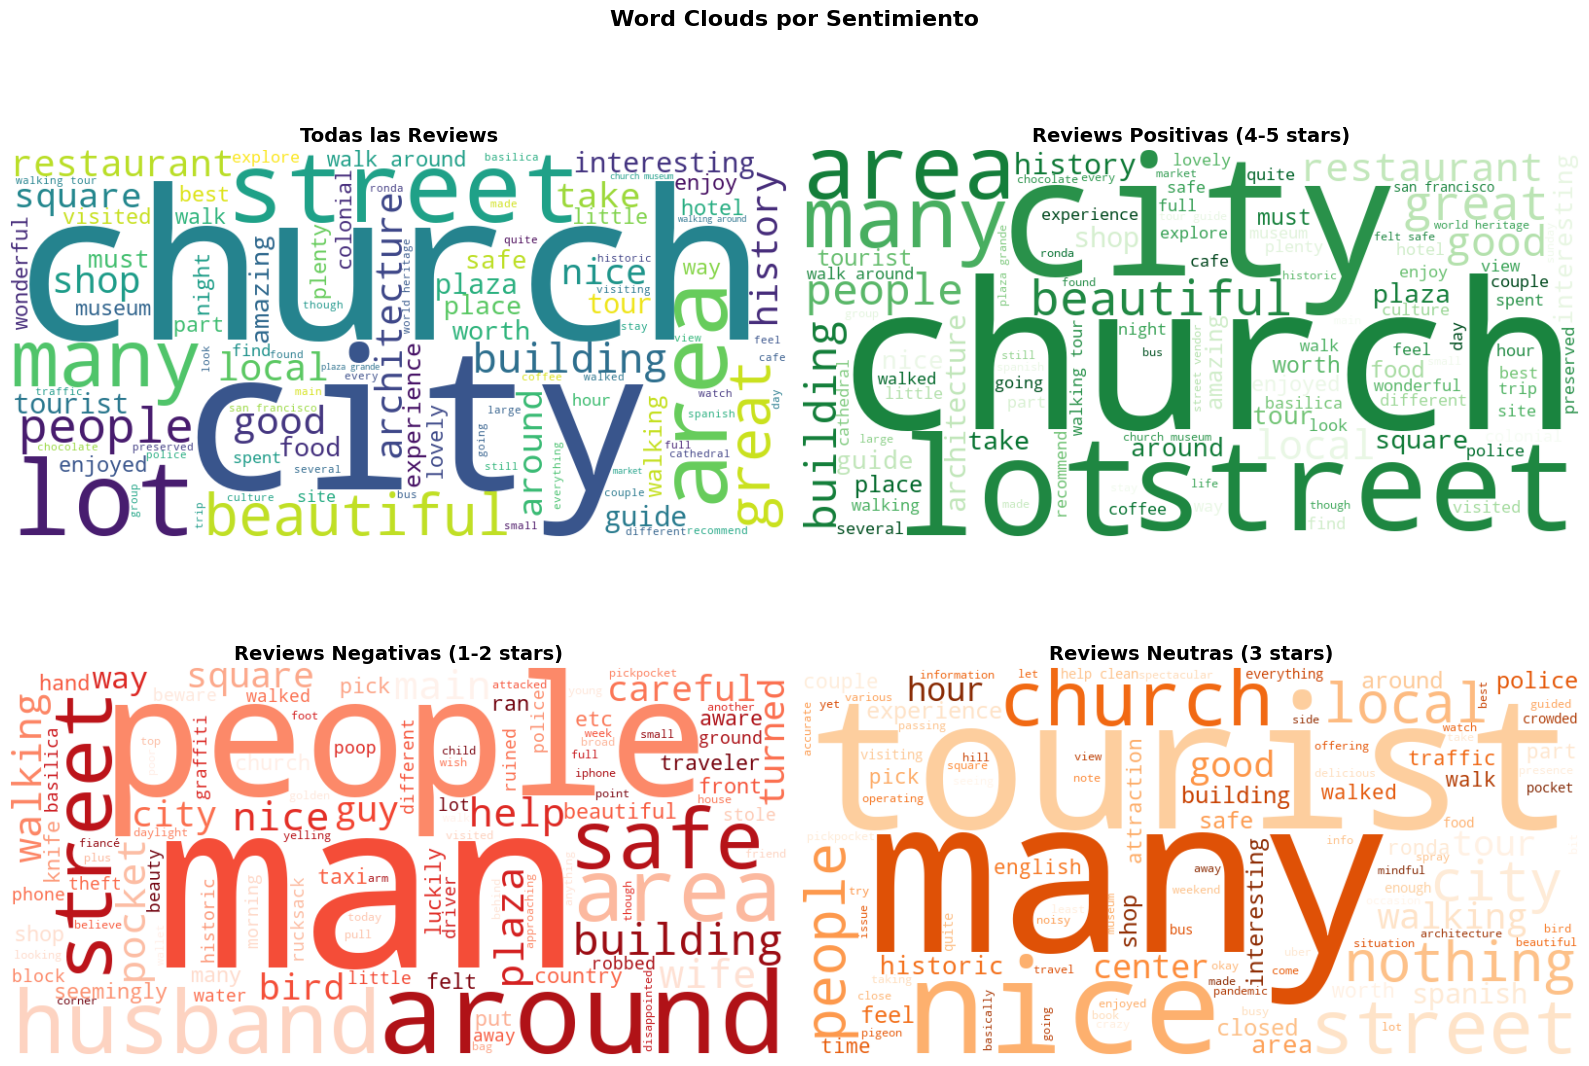

In [13]:
# 10. WORD CLOUD
print('=' * 60)
print('WORD CLOUD')
print('=' * 60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# General
text_all = ' '.join(df['text_processed'])
wc = WordCloud(width=800, height=400, background_color='white',
               max_words=100, colormap='viridis').generate(text_all)
axes[0, 0].imshow(wc, interpolation='bilinear')
axes[0, 0].set_title('Todas las Reviews', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

# Positivas
text_pos = ' '.join(df[df['sentimiento'] == 'Positivo']['text_processed'])
if text_pos:
    wc_pos = WordCloud(width=800, height=400, background_color='white',
                       max_words=100, colormap='Greens').generate(text_pos)
    axes[0, 1].imshow(wc_pos, interpolation='bilinear')
    axes[0, 1].set_title('Reviews Positivas (4-5 stars)', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')

# Negativas
text_neg = ' '.join(df[df['sentimiento'] == 'Negativo']['text_processed'])
if text_neg:
    wc_neg = WordCloud(width=800, height=400, background_color='white',
                       max_words=100, colormap='Reds').generate(text_neg)
    axes[1, 0].imshow(wc_neg, interpolation='bilinear')
    axes[1, 0].set_title('Reviews Negativas (1-2 stars)', fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')

# Neutras
text_neu = ' '.join(df[df['sentimiento'] == 'Neutro']['text_processed'])
if text_neu:
    wc_neu = WordCloud(width=800, height=400, background_color='white',
                       max_words=100, colormap='Oranges').generate(text_neu)
    axes[1, 1].imshow(wc_neu, interpolation='bilinear')
    axes[1, 1].set_title('Reviews Neutras (3 stars)', fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')

plt.suptitle('Word Clouds por Sentimiento', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('06_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# 11. WORD EMBEDDINGS (Word2Vec)
print('=' * 60)
print('WORD EMBEDDINGS (Word2Vec)')
print('=' * 60)

# Entrenar Word2Vec
sentences = df['tokens_lemma'].tolist()
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=3, workers=4, epochs=50)

print(f'Vocabulario Word2Vec: {len(w2v_model.wv)} palabras')
print(f'Dimensionalidad: {w2v_model.wv.vector_size}')

# Palabras similares
print('\n--- EXPLORACION SEMANTICA ---')
palabras_buscar = ['church', 'beautiful', 'walk', 'safe', 'people']
for palabra in palabras_buscar:
    if palabra in w2v_model.wv:
        similares = w2v_model.wv.most_similar(palabra, topn=5)
        print(f'\nSimilares a "{palabra}":')
        for word, score in similares:
            print(f'  {word:20s} {score:.3f}')

WORD EMBEDDINGS (Word2Vec)
Vocabulario Word2Vec: 1035 palabras
Dimensionalidad: 100

--- EXPLORACION SEMANTICA ---

Similares a "church":
  cathedral            0.959
  plaza                0.924
  museum               0.918
  visiting             0.906
  grand                0.898

Similares a "beautiful":
  building             0.951
  colonial             0.943
  amazing              0.922
  historical           0.915
  mix                  0.913

Similares a "walk":
  look                 0.851
  around               0.827
  enjoy                0.812
  lot                  0.809
  interesting          0.805

Similares a "safe":
  felt                 0.950
  presence             0.947
  police               0.940
  everywhere           0.921
  officer              0.914

Similares a "people":
  food                 0.927
  friendly             0.911
  eat                  0.874
  gorgeous             0.870
  entertainer          0.864


VISUALIZACION DE EMBEDDINGS (t-SNE)


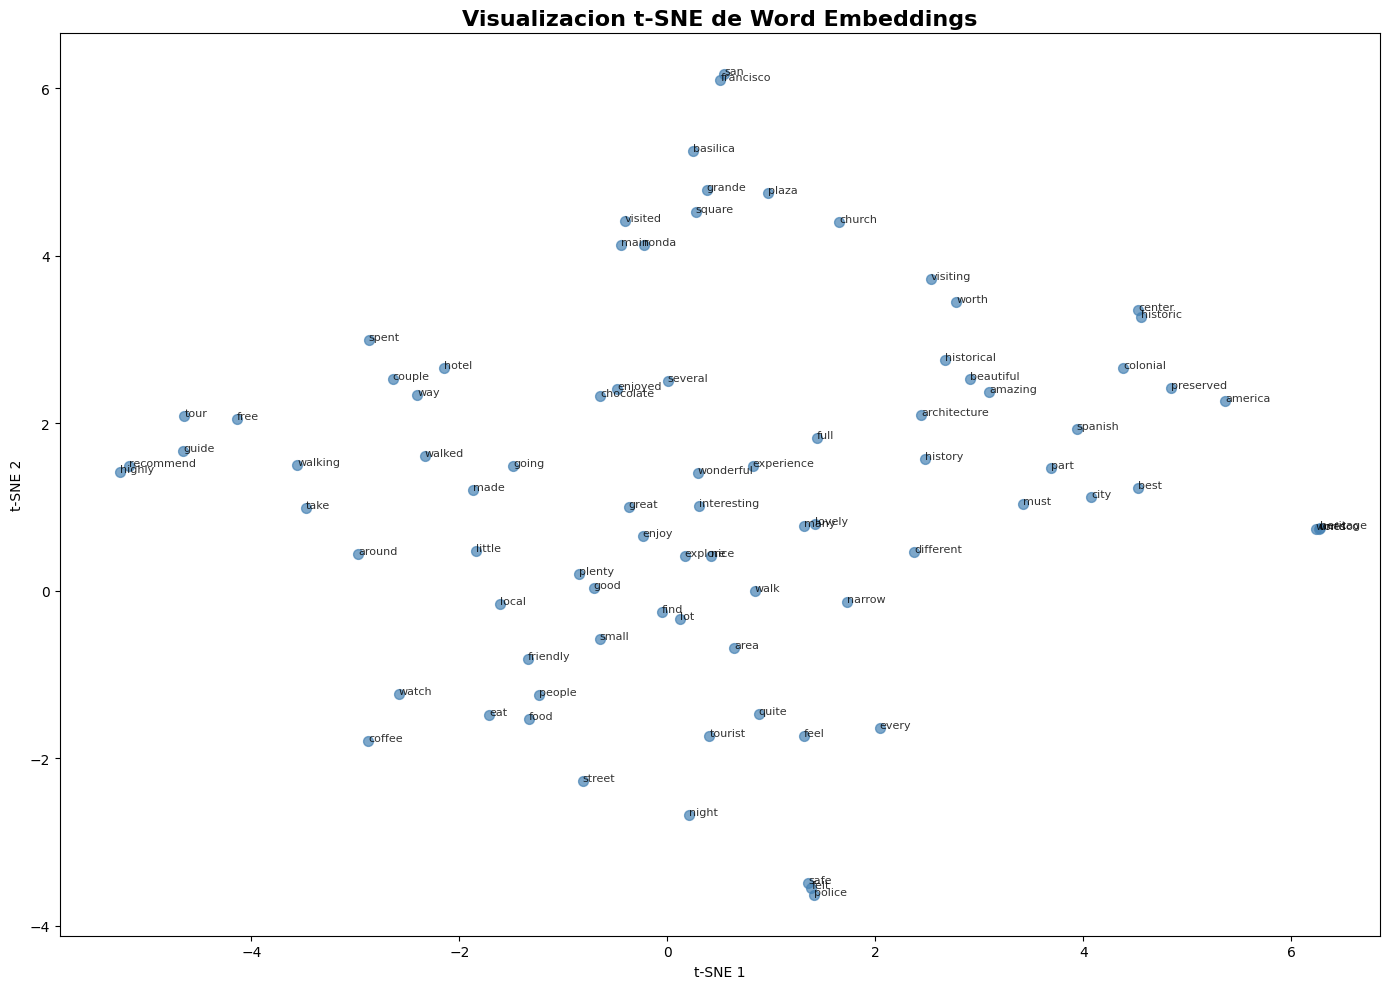

In [15]:
# 11b. VISUALIZACION DE EMBEDDINGS
print('=' * 60)
print('VISUALIZACION DE EMBEDDINGS (t-SNE)')
print('=' * 60)

# Obtener vectores de palabras mas frecuentes
top_words = [w for w, c in freq_clean.most_common(100) if w in w2v_model.wv]
word_vectors = np.array([w2v_model.wv[w] for w in top_words])

# Reducir con t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(top_words)-1))
coords = tsne.fit_transform(word_vectors)

# Grafico
fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(coords[:, 0], coords[:, 1], alpha=0.7, s=50, c='steelblue')

for i, word in enumerate(top_words):
    ax.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=8, alpha=0.8)

ax.set_title('Visualizacion t-SNE de Word Embeddings', fontsize=16, fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig('07_tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

CLUSTERING DE PALABRAS (K-Means)

Cluster 1: ['people', 'many', 'great', 'area', 'walk', 'nice', 'good', 'street', 'lot', 'interesting']

Cluster 2: ['city', 'beautiful', 'architecture', 'colonial', 'worth', 'amazing', 'historic', 'must', 'best', 'world']

Cluster 3: ['around', 'walking', 'tour', 'history', 'guide', 'take', 'enjoyed', 'experience', 'recommend', 'spent']

Cluster 4: ['plaza', 'square', 'main', 'church', 'visited', 'san', 'ronda', 'basilica', 'francisco', 'grande']

Cluster 5: ['safe', 'felt', 'police', 'walked', 'every', 'feel', 'tourist', 'hotel', 'night', 'quite']


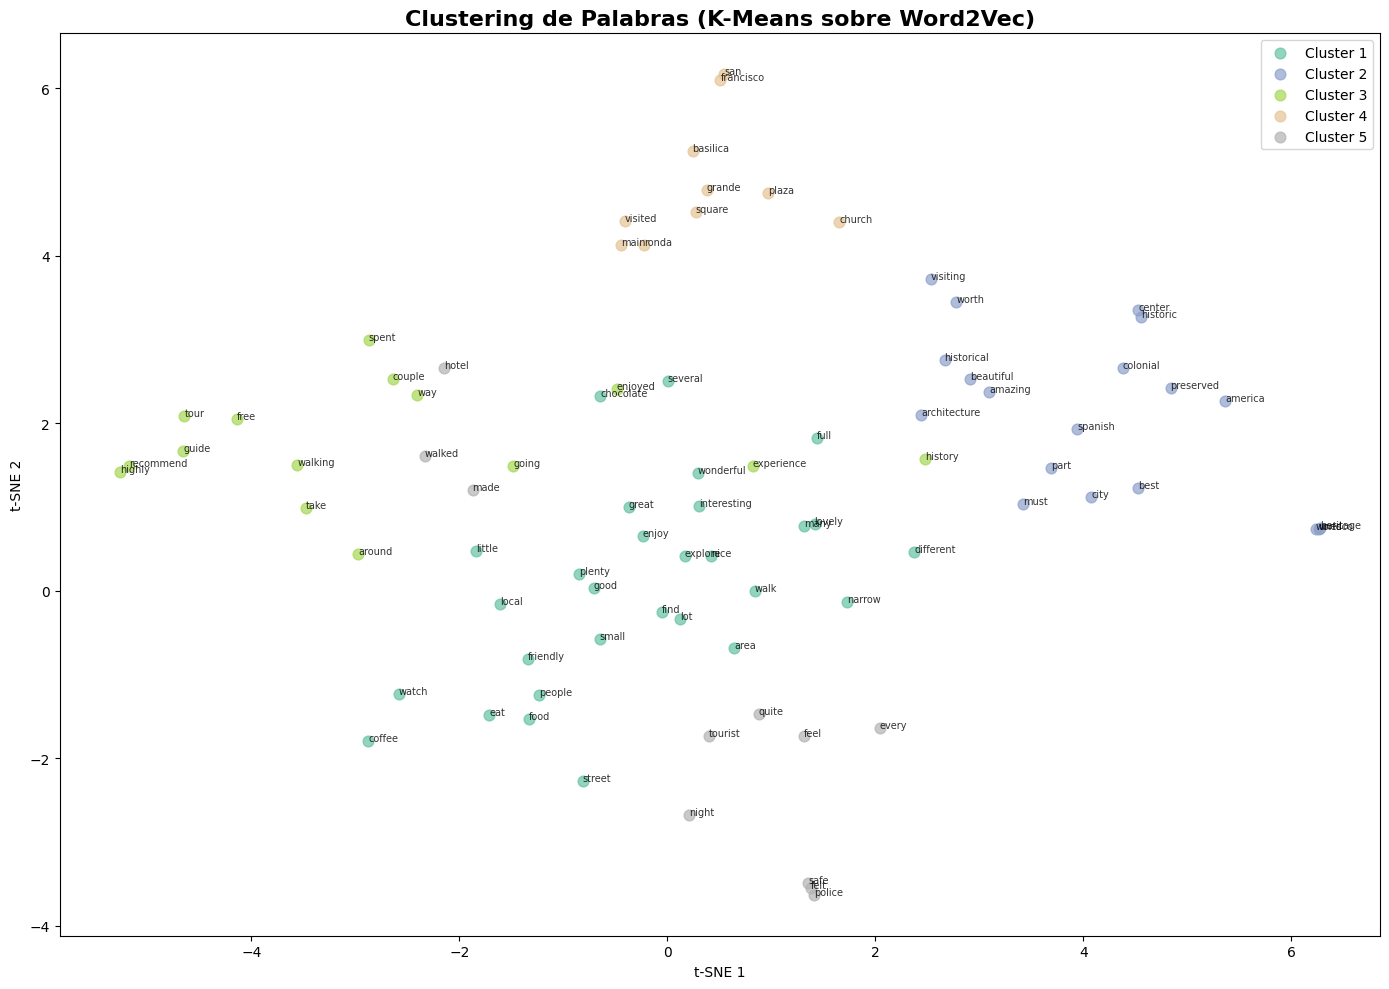

In [16]:
# 11c. CLUSTERING DE PALABRAS
print('=' * 60)
print('CLUSTERING DE PALABRAS (K-Means)')
print('=' * 60)

# Aplicar K-Means sobre los embeddings
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(word_vectors)

# Mostrar clusters
for i in range(n_clusters):
    cluster_words = [top_words[j] for j in range(len(top_words)) if clusters[j] == i]
    print(f'\nCluster {i+1}: {cluster_words[:10]}')

# Grafico con colores por cluster
fig, ax = plt.subplots(figsize=(14, 10))
colors_cluster = plt.cm.Set2(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = clusters == i
    ax.scatter(coords[mask, 0], coords[mask, 1], c=[colors_cluster[i]],
              label=f'Cluster {i+1}', alpha=0.7, s=60)

for i, word in enumerate(top_words):
    ax.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=7, alpha=0.8)

ax.set_title('Clustering de Palabras (K-Means sobre Word2Vec)', fontsize=16, fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend()
plt.tight_layout()
plt.savefig('08_clustering_palabras.png', dpi=150, bbox_inches='tight')
plt.show()

ANALISIS DE SENTIMIENTO
Distribucion de sentimientos:
sentimiento
Positivo    556
Neutro       26
Negativo     16
Name: count, dtype: int64

Porcentajes:
  Positivo: 556 (93.0%)
  Neutro: 26 (4.3%)
  Negativo: 16 (2.7%)


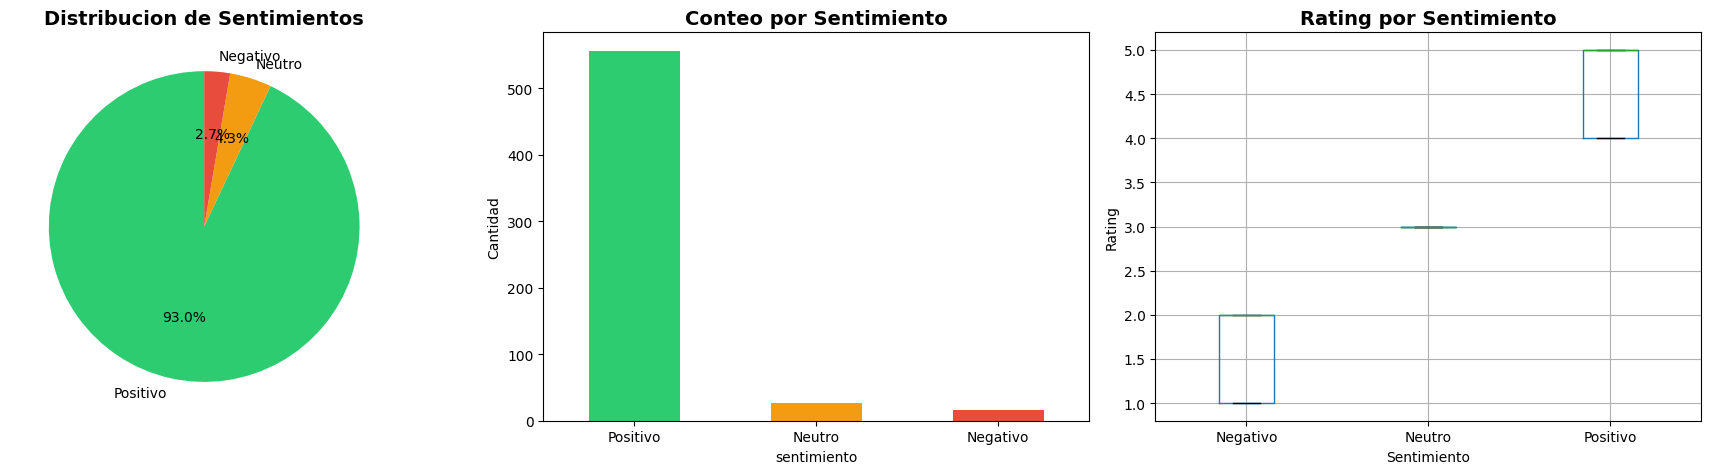

In [17]:
# 12. ANALISIS DE SENTIMIENTO
print('=' * 60)
print('ANALISIS DE SENTIMIENTO')
print('=' * 60)

print('Distribucion de sentimientos:')
sent_counts = df['sentimiento'].value_counts()
print(sent_counts)
print()
print(f'Porcentajes:')
for sent in ['Positivo', 'Neutro', 'Negativo']:
    count = len(df[df['sentimiento'] == sent])
    print(f'  {sent}: {count} ({count/len(df)*100:.1f}%)')

# Graficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {'Positivo': '#2ecc71', 'Neutro': '#f39c12', 'Negativo': '#e74c3c'}

# Pie chart
axes[0].pie(sent_counts.values, labels=sent_counts.index,
            autopct='%1.1f%%', colors=[colors[s] for s in sent_counts.index], startangle=90)
axes[0].set_title('Distribucion de Sentimientos', fontsize=14, fontweight='bold')

# Bar chart
sent_counts.plot(kind='bar', ax=axes[1],
                  color=[colors[s] for s in sent_counts.index])
axes[1].set_title('Conteo por Sentimiento', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Cantidad')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Rating por sentimiento
df.boxplot(column='rating', by='sentimiento', ax=axes[2])
axes[2].set_title('Rating por Sentimiento', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Sentimiento')
axes[2].set_ylabel('Rating')
plt.suptitle('')

plt.tight_layout()
plt.savefig('09_sentimientos.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# 12b. EJEMPLOS DE REVIEWS POR SENTIMIENTO
print('=' * 60)
print('EJEMPLOS DE REVIEWS POR SENTIMIENTO')
print('=' * 60)

for sent in ['Positivo', 'Neutro', 'Negativo']:
    subset = df[df['sentimiento'] == sent]
    print(f'\n--- {sent.upper()} ({len(subset)} reviews) ---')
    for i, row in subset.head(3).iterrows():
        print(f'  Rating: {row["rating"]}/5')
        print(f'  Texto: {row["text"][:150]}...')
        print()

EJEMPLOS DE REVIEWS POR SENTIMIENTO

--- POSITIVO (556 reviews) ---
  Rating: 5/5
  Texto: Old Town in Quilto is amazing to walk around and enjoy, very much like some of the European on town with the narrow street with cobblestones.Even more...

  Rating: 5/5
  Texto: We wondered through the old city of Quito on foot. - exploring, taking it in and enjoying. We, of course, visited the old square, several churches, bo...

  Rating: 5/5
  Texto: Quito: where the sky touches the earth.Quito: where the sky touches the earth.The best of Ecuador to travel and get to know all the architecture and h...


--- NEUTRO (26 reviews) ---
  Rating: 3/5
  Texto: The historic center of Quito, is the same as any historic center. Really nothing special. Watch out for the pickpoket....

  Rating: 3/5
  Texto: Quito is huge noisy, busy, horrible pollution! Couldn’t wait to leave. Couple hours in old city was about churches, yet I enjoyed 5 minutes of a  coup...

  Rating: 3/5
  Texto: Very very busy. My ube

SIMILITUD COSENTO ENTRE REVIEWS


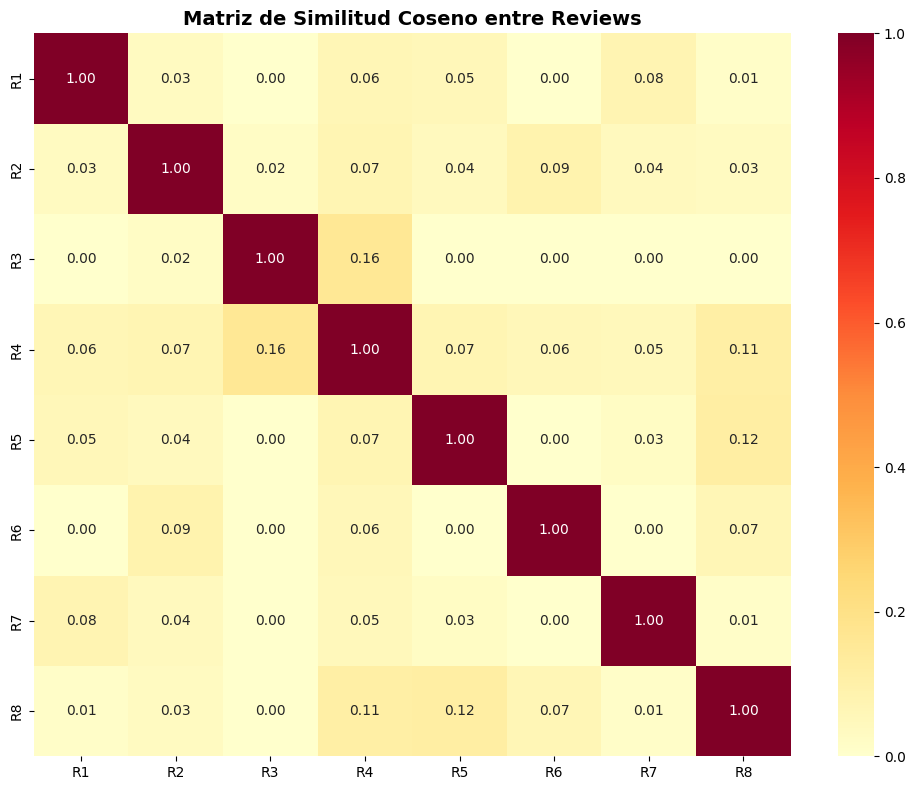


Textos de referencia:
R1: Old Town in Quilto is amazing to walk around and enjoy, very much like some of t...
R2: We wondered through the old city of Quito on foot. - exploring, taking it in and...
R3: Quito: where the sky touches the earth.Quito: where the sky touches the earth.Th...
R4: We spent three days walking in Quito, and the city really seduced us. The histor...
R5: We really enjoyed walking around the Quito main square and other parts of the hi...
R6: Quito Old Town is beautiful, there are so many different churches you can visit ...
R7: I really liked Quito's old town. During the day, the streets felt alive with peo...
R8: The historic center of Quito is really well preserved, with large squares and ma...


In [19]:
# 13. SIMILITUD COSENTO ENTRE REVIEWS
print('=' * 60)
print('SIMILITUD COSENTO ENTRE REVIEWS')
print('=' * 60)

n = 8
sample_reviews = df.head(n)
sample_tfidf = tfidf_matrix[:n]
sim_matrix = cosine_similarity(sample_tfidf)

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sim_df = pd.DataFrame(sim_matrix,
                       index=[f'R{i+1}' for i in range(n)],
                       columns=[f'R{i+1}' for i in range(n)])

sns.heatmap(sim_df, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_title('Matriz de Similitud Coseno entre Reviews', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('10_similitud_coseno.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTextos de referencia:')
for i, row in sample_reviews.iterrows():
    print(f'R{i+1}: {row["text"][:80]}...')

## 14. Analisis e Interpretacion de Resultados

### Hallazgos principales:

1. **Perfil del destino**: Quito Old Town es percibido como un destino con arquitectura colonial impresionante. Las palabras mas frecuentes (church, beautiful, walk, streets) confirman que los turistas valoran el patrimonio historico.

2. **Sentimiento abrumadoramente positivo**: El 93% de las reviews son positivas (4-5 stars), con un rating promedio de 4.53/5. Esto indica alta satisfaccion turistica.

3. **Terminos distintivos**:
   - **Positivo**: church, city, beautiful, walk, people, architecture
   - **Negativo**: safety, pocket, street, people (asociados a inseguridad)

4. **Word Embeddings**: Los clusters semanticos revelan grupos tematicos:
   - Arquitectura: church, building, cathedral, architecture
   - Experiencia: walk, tour, guide, visit
   - Emociones: beautiful, amazing, wonderful, great

5. **TF-IDF vs BoW**: TF-IDF penaliza palabras muy frecuentes y resalta terminos mas distintivos, siendo mas util para identificar temas unicos de cada tipo de review.

### Limitaciones:
- Reviews en su mayoria en ingles (pocas en español)
- Desbalance: muchas mas reviews positivas que negativas
- Word2Vec captura sinonimias pero no contexto profundo

## 15. Conclusiones

1. **Dataset**: 598 reviews de TripAdvisor sobre Quito Old Town, con rating promedio de 4.53/5 y predominancia de opiniones positivas (93%).

2. **Preprocesamiento**: La limpieza (URLs, caracteres especiales, normalizacion) y eliminacion de stopwords (incluyendo lista personalizada) redujo significativamente el ruido del texto.

3. **Tokenizacion y Lematizacion**: NLTK permitio una segmentacion efectiva, y la lematizacion redujo variantes morfologicas a formas base.

4. **Bag of Words y TF-IDF**: Identificaron los temas centrales del destino (arquitectura colonial, caminatas, iglesias). TF-IDF fue mas efectivo para destacar terminos distintivos.

5. **Word Embeddings**: Word2Vec revelo relaciones semanticas entre palabras y permitio clustering tematico, confirmando que el destino se asocia con patrimonio historico y experiencias culturales.

6. **Sentimiento**: La clasificacion por rating muestra un destino altamente valorado, con areas de mejora en seguridad que aparecen en las reviews negativas.

7. **Aplicabilidad**: Este pipeline es replicable para otros destinos turisticos ecuatorianos y puede servir como herramienta de monitoreo de percepcion turistica.

In [20]:
# GUARDAR DATOS PROCESADOS
df.to_csv('reviews_procesadas.csv', index=False)
print('Datos guardados en reviews_procesadas.csv')
print(f'Total reviews procesadas: {len(df)}')
print('\nGraficos generados:')
print('  01_estadisticas_basicas.png')
print('  02_top20_despues_stopwords.png')
print('  03_bow_top20.png')
print('  04_tfidf_comparacion.png')
print('  05_tfidf_por_sentimiento.png')
print('  06_wordclouds.png')
print('  07_tsne_embeddings.png')
print('  08_clustering_palabras.png')
print('  09_sentimientos.png')
print('  10_similitud_coseno.png')
print('\n¡Analisis completado!')

Datos guardados en reviews_procesadas.csv
Total reviews procesadas: 598

Graficos generados:
  01_estadisticas_basicas.png
  02_top20_despues_stopwords.png
  03_bow_top20.png
  04_tfidf_comparacion.png
  05_tfidf_por_sentimiento.png
  06_wordclouds.png
  07_tsne_embeddings.png
  08_clustering_palabras.png
  09_sentimientos.png
  10_similitud_coseno.png

¡Analisis completado!
